In [129]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit


nrounds = np.array([1, 2, 3, 4, 5, 10, 20, 30, 40, 50])
ers = np.array([0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005])
linestyles = ['-', '--', ':', '-.']
plotting_space1 = np.linspace(0, nrounds[-1], 100)
plotting_space2 = np.linspace(0, ers[-1], 100)

def exponential_relaxation(x, a, b):
    return a * np.exp(-b * x) + 0.5


# Columns:
# logical_errors/nsamples, 
# outside_codespace/nsamples, 
# detector_fires/nsamples, 
# detector_fires_Z/nsamples, 
# detector_fires_X/nsamples, 
# successful_corrections/nsamples, 
# harmful_corrections/nsamples


In [107]:
data1 = pickle.load(open('hamming15_results_with_correction.pkl', 'rb'))
data1 = np.asarray(data1)
data2 = pickle.load(open('hamming15_results_with_correction_decomp.pkl', 'rb'))
data2 = np.asarray(data2)
data3 = pickle.load(open('hamming15_results_without_correction.pkl', 'rb'))
data3 = np.asarray(data3)
data4 = pickle.load(open('hamming15_results_without_correction_decomp.pkl', 'rb'))
data4 = np.asarray(data4)
datas = [data1, data2, data3, data4]
print(data1.shape)

(6, 10, 7)


In [15]:
logical_errors1 = data1[0, :, 0]
logical_errors2 = data2[0, :, 0]
print(logical_errors1)
print(logical_errors2)

[0.0399 0.0572 0.0684 0.0884 0.1084 0.1837 0.2853 0.3584 0.407  0.445 ]
[0.0228 0.0299 0.0459 0.0535 0.0608 0.106  0.1901 0.2619 0.2972 0.3391]


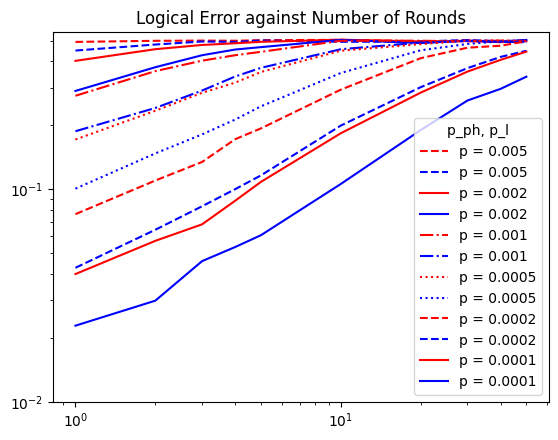

In [47]:
for i in range(len(ers) - 1, -1, -1):
    logical_errors1 = data1[i, :, 0]
    logical_errors2 = data2[i, :, 0]
    plt.plot(nrounds, logical_errors1, color = 'red', label = 'p = ' + str(ers[i]), linestyle = linestyles[i % len(linestyles)])
    plt.plot(nrounds, logical_errors2, color = 'blue', label = 'p = ' + str(ers[i]), linestyle = linestyles[i % len(linestyles)])
plt.ylim(0.01, 0.55)
plt.yscale('log')
plt.xscale('log')
plt.title('Logical Error against Number of Rounds')
plt.legend(loc='lower right', title='p_ph, p_l')
plt.show()

0.17614 0.38922 0.10582 0.22057
0.09947 0.203 0.05607 0.11079
0.03863 0.08239 0.02316 0.0445
0.01713 0.04132 0.01061 0.02265


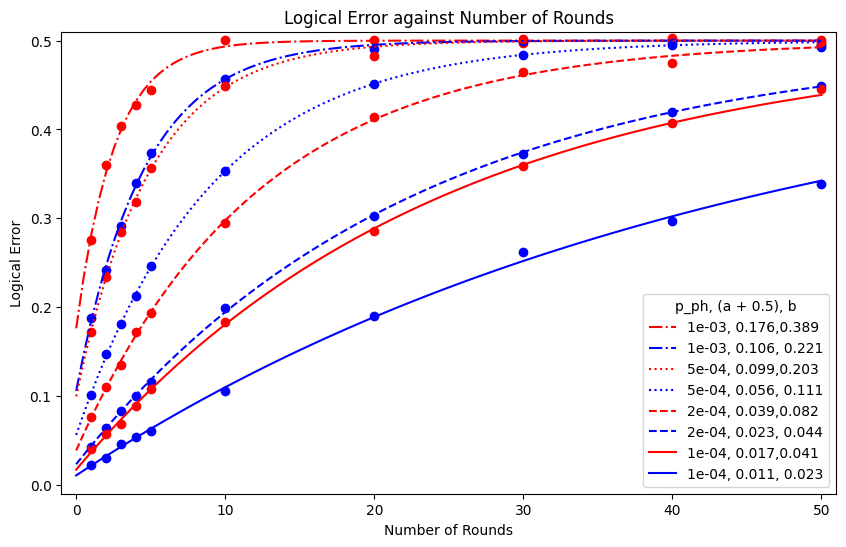

In [131]:
# Logical Error against Number of Rounds
plt.figure(figsize = (10, 6))
for i in range(len(ers) - 3, -1, -1):
    logical_errors1 = data1[i, :, 0]
    logical_errors2 = data2[i, :, 0]
    plt.scatter(nrounds, logical_errors1, color = 'red')
    plt.scatter(nrounds, logical_errors2, color = 'blue')
    popt, _ = curve_fit(exponential_relaxation, nrounds, logical_errors1)
    popt2, _ = curve_fit(exponential_relaxation, nrounds, logical_errors2)
    plt.plot(
        plotting_space1, 
        exponential_relaxation(plotting_space1, *popt), 
        color='red', 
        linestyle=linestyles[i % len(linestyles)],
        label=f'{ers[i]:.0e}, {round(popt[0] + 0.5, 3)},{round(popt[1], 3)}'
    )
    plt.plot(
        plotting_space1, 
        exponential_relaxation(plotting_space1, *popt2), 
        color = 'blue', 
        linestyle = linestyles[i % len(linestyles)], 
        label = f'{ers[i]:.0e}, {round(popt2[0] + 0.5, 3)}, {round(popt2[1], 3)}'
    )
    print(round(popt[0] + 0.5, 5), round(popt[1], 5), round(popt2[0] + 0.5, 5), round(popt2[1], 5))
plt.ylim(-0.01, 0.51)
plt.xlim(-1, 51)
plt.legend(loc='lower right', title='p_ph, (a + 0.5), b')
plt.title('Logical Error against Number of Rounds')
plt.xlabel('Number of Rounds')
plt.ylabel('Logical Error')
plt.show()

0.02342 0.04533 0.01061 0.02265
0.01116 0.02272 0.01061 0.02265


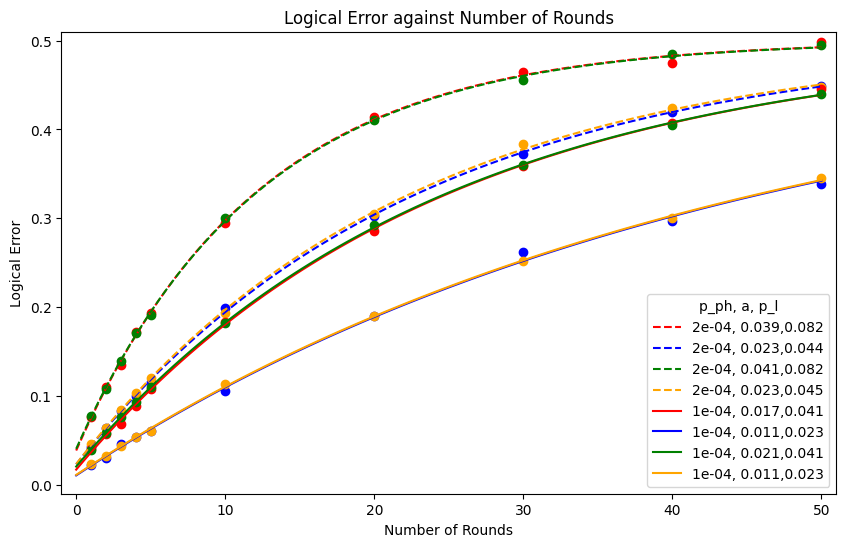

In [106]:
# Logical Error against Number of Rounds
plt.figure(figsize = (10, 6))
for i in range(len(ers) - 5, -1, -1):
    colors = ['red', 'blue', 'green', 'orange']
    popts = []
    for j, (data, color) in enumerate(zip(datas, colors)):
        logical_errors = data[i, :, 0]
        plt.scatter(nrounds, logical_errors, color=color)
        popt, _ = curve_fit(exponential_relaxation, nrounds, logical_errors)
        popts.append(popt)
        plt.plot(
            plotting_space1, 
            exponential_relaxation(plotting_space1, *popt), 
            color=color, 
            linestyle=linestyles[i % len(linestyles)],
            label=f'{ers[i]:.0e}, {round(popt[0]+0.5,3)},{round(popt[1],3)}'
        )
    print(round(popt[0] + 0.5, 5), round(popt[1], 5), round(popt2[0] + 0.5, 5), round(popt2[1], 5))
plt.ylim(-0.01, 0.51)
plt.xlim(-1, 51)
plt.legend(loc='lower right', title='p_ph, a, p_l')
plt.title('Logical Error against Number of Rounds')
plt.xlabel('Number of Rounds')
plt.ylabel('Logical Error')
plt.show()

-0.94052 32654.27768 -0.00161 11377.08636
0.1597 12966.67271 -0.01909 9391.89826
-0.06411 13820.54576 0.04944 6353.51155
-0.01521 8799.17094 0.0108 4557.74078
0.00044 4520.63867 -0.00192 2489.01071
0.00538 2384.53748 -0.00449 1374.92897
0.00355 1988.46316 -0.00308 1149.20699
-0.01046 1688.03662 5e-05 909.51163
-0.00226 1268.35733 -0.001 683.09246
0.00181 813.11535 0.00102 448.99628


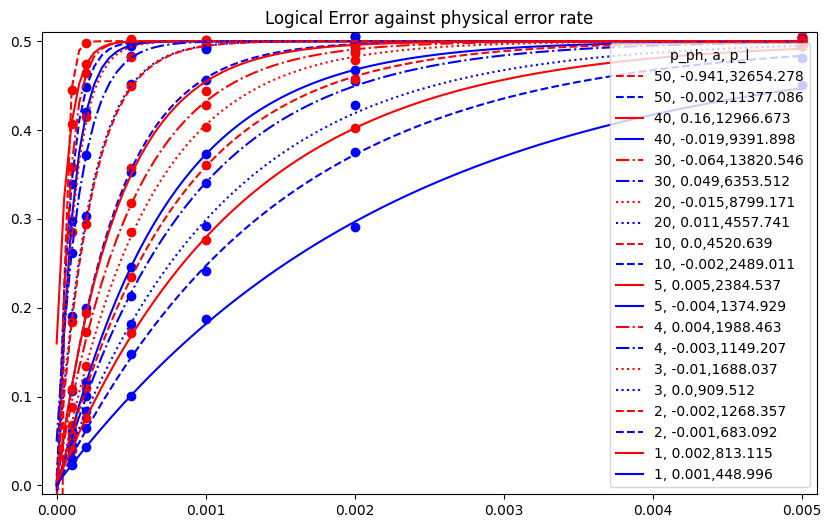

In [100]:
plt.figure(figsize = (10, 6))
for i in range(len(nrounds) - 1, -1, -1):
    if True:
        logical_errors1 = data1[:, i, 0]
        logical_errors2 = data2[:, i, 0]
        plt.scatter(ers, logical_errors1, color = 'red')
        plt.scatter(ers, logical_errors2, color = 'blue')
        popt, _ = curve_fit(exponential_relaxation, ers, logical_errors1)
        popt2, _ = curve_fit(exponential_relaxation, ers, logical_errors2)
        plt.plot(
            plotting_space2, 
            exponential_relaxation(plotting_space2, *popt), 
            color='red', 
            linestyle=linestyles[i % len(linestyles)],
            label=f'{nrounds[i]}, {round(popt[0] + 0.5, 3)},{round(popt[1], 3)}'
        )
        plt.plot(
            plotting_space2, 
            exponential_relaxation(plotting_space2, *popt2), 
            color = 'blue', 
            linestyle = linestyles[i % len(linestyles)], 
            label = f'{nrounds[i]}, {round(popt2[0] + 0.5, 3)},{round(popt2[1], 3)}'
        )
        print(round(popt[0] + 0.5, 5), round(popt[1], 5), round(popt2[0] + 0.5, 5), round(popt2[1], 5))
plt.ylim(-0.01, 0.51)
plt.xlim(-0.0001, 0.0051)
plt.legend(loc='lower right', title='p_ph, a, p_l')
plt.title('Logical Error against physical error rate')
plt.show()

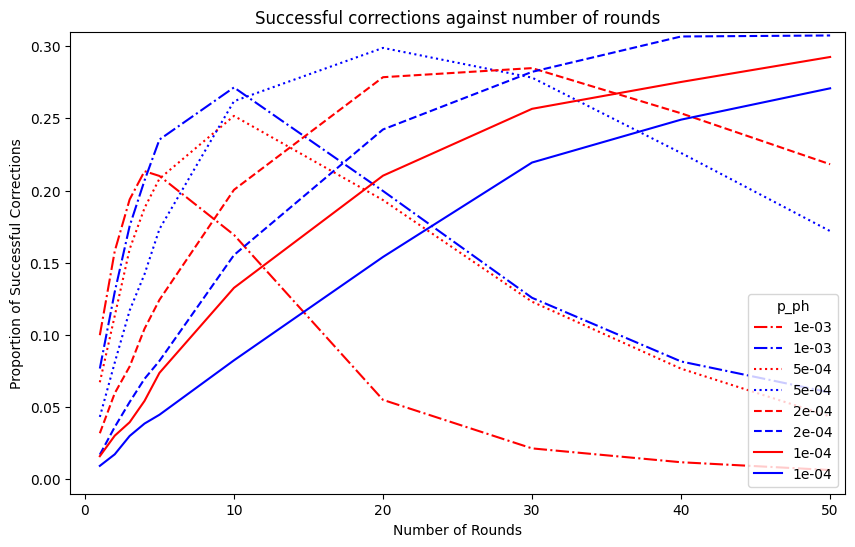

In [ ]:
# Successful Corrections
plt.figure(figsize = (10, 6))
for i in range(len(ers) - 3, -1, -1):
    logical_errors1 = data1[i, :, 5]
    logical_errors2 = data2[i, :, 5]
    plt.plot(nrounds, logical_errors1, color = 'red', linestyle = linestyles[i % len(linestyles)], label = f'{ers[i]:.0e}')
    plt.plot(nrounds, logical_errors2, color = 'blue', linestyle = linestyles[i % len(linestyles)], label = f'{ers[i]:.0e}')
plt.ylim(-0.01, 0.31)
plt.xlim(-1, 51)
plt.legend(loc='lower right', title='p_ph')
plt.title('Successful corrections against number of rounds')
plt.xlabel('Number of Rounds')
plt.ylabel('Proportion of Successful Corrections')
plt.show()

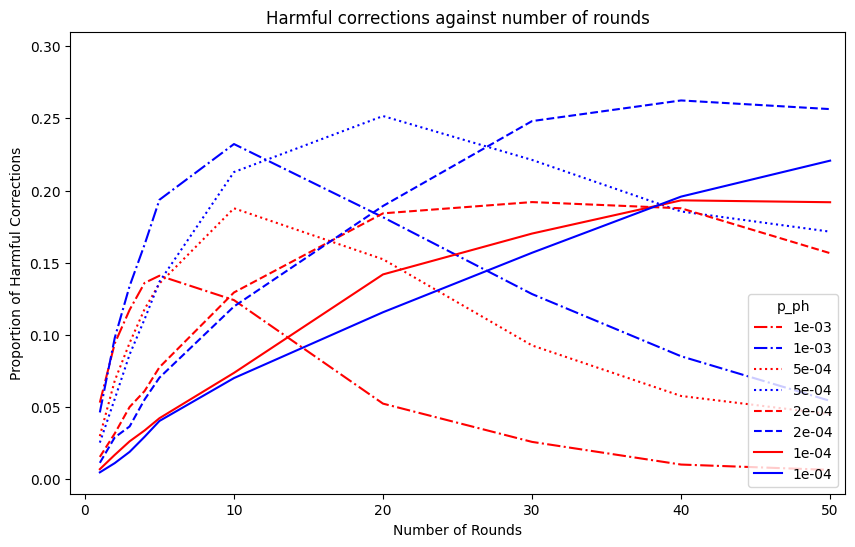

In [122]:
# Harmful Corrections
plt.figure(figsize = (10, 6))
for i in range(len(ers) - 3, -1, -1):
    logical_errors1 = data1[i, :, 6]
    logical_errors2 = data2[i, :, 6]
    plt.plot(nrounds, logical_errors1, color = 'red', linestyle = linestyles[i % len(linestyles)], label = f'{ers[i]:.0e}')
    plt.plot(nrounds, logical_errors2, color = 'blue', linestyle = linestyles[i % len(linestyles)], label = f'{ers[i]:.0e}')
plt.ylim(-0.01, 0.31)
plt.xlim(-1, 51)
plt.legend(loc='lower right', title='p_ph')
plt.title('Harmful corrections against number of rounds')
plt.xlabel('Number of Rounds')
plt.ylabel('Proportion of Harmful Corrections')
plt.show()

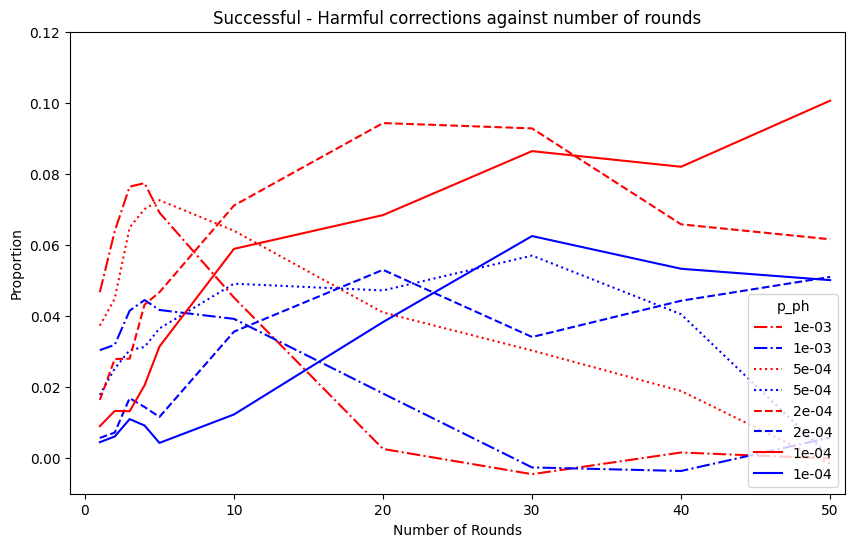

In [133]:
# Successful - harmful
plt.figure(figsize = (10, 6))
for i in range(len(ers) - 3, -1, -1):
    logical_errors1 = data1[i, :, 5] - data1[i, :, 6]
    logical_errors2 = data2[i, :, 5] - data2[i, :, 6]
    plt.plot(nrounds, logical_errors1, color = 'red', linestyle = linestyles[i % len(linestyles)], label = f'{ers[i]:.0e}')
    plt.plot(nrounds, logical_errors2, color = 'blue', linestyle = linestyles[i % len(linestyles)], label = f'{ers[i]:.0e}')
plt.ylim(-0.01, 0.12)
plt.xlim(-1, 51)
plt.legend(loc='lower right', title='p_ph')
plt.title('Successful - Harmful corrections against number of rounds')
plt.xlabel('Number of Rounds')
plt.ylabel('Proportion')
plt.show()

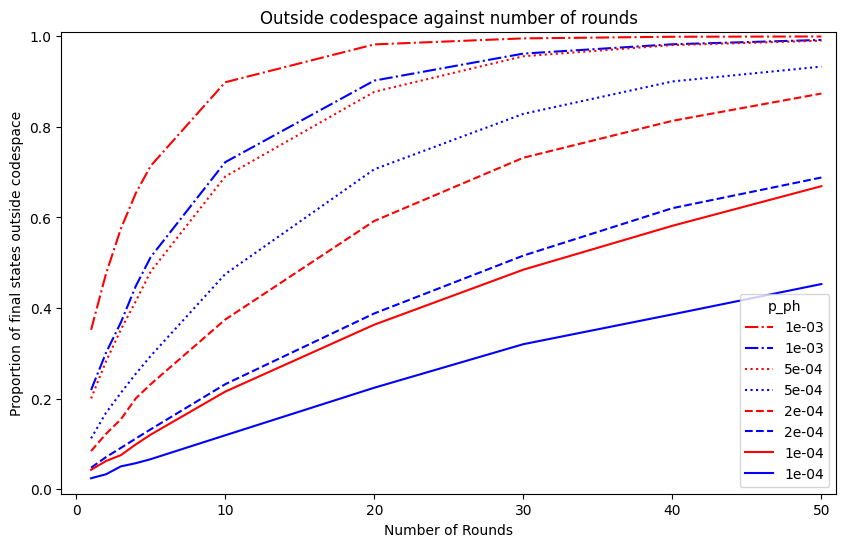

In [127]:
# Left codespace
plt.figure(figsize = (10, 6))
for i in range(len(ers) - 3, -1, -1):
    logical_errors1 = data1[i, :, 1]
    logical_errors2 = data2[i, :, 1]
    plt.plot(nrounds, logical_errors1, color = 'red', linestyle = linestyles[i % len(linestyles)], label = f'{ers[i]:.0e}')
    plt.plot(nrounds, logical_errors2, color = 'blue', linestyle = linestyles[i % len(linestyles)], label = f'{ers[i]:.0e}')
plt.ylim(-0.01, 1.01)
plt.xlim(-1, 51)
plt.legend(loc='lower right', title='p_ph')
plt.title('Outside codespace against number of rounds')
plt.xlabel('Number of Rounds')
plt.ylabel('Proportion of final states outside codespace')
plt.show()